In [37]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib.font_manager as font_manager

In [38]:
font_path = "/home/z3536241/Fonts/arial.ttf"
font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name

plt.rcParams['svg.fonttype'] = 'none'

## load layouts from files

In [39]:
Experiment1Layout = pd.read_csv("/home/z3536241/src/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mACmChPOLR2A_ARMC5/250825_mACmChPOLR2A_ARMC5/METADATA/250825_mACmChPOLR2A_ARMC5.csv")
Experiment2Layout = pd.read_csv("/home/z3536241/src/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mACmChPOLR2A_ARMC5/250908_mACmChPOLR2A_ARMC5/METADATA/250908_mACmChPOLR2A_ARMC5.csv")

## load quantification files from relevant directories, and assemble into data frames

In [40]:
Experiment1_Quantification_Directory = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/250825_mACmChPOLR2A_ARMC5/20250829_183212_390/QUANTIFICATION/")
Experiment1_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory / "*.csv"))

Experiment2_Quantification_Directory = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/250908_mACmChPOLR2A_ARMC5/20250914_193054_992/QUANTIFICATION/")
Experiment2_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory / "*.csv"))

len(Experiment1_Quantification_Files), len(Experiment2_Quantification_Files)

(946, 949)

In [41]:
qdfs = list()


for f in tqdm(Experiment1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment1_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment1_PerCell['fov'] = fovs

Experiment1_Intensities = pd.DataFrame({
    "WELL" : Experiment1_PerCell['well'],
    "IF_647_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_647'],
    "RFP_561_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_561'],
    "GFP_488_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment1_PerCell['Nuclei_area']
})

100%|██████████| 946/946 [00:24<00:00, 38.38it/s]


In [42]:
qdfs = list()


for f in tqdm(Experiment2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment2_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment2_PerCell['fov'] = fovs

Experiment2_Intensities = pd.DataFrame({
    "WELL" : Experiment2_PerCell['well'],
    "IF_647_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_647'],
    "RFP_561_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_561'],
    "GFP_488_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment2_PerCell['Nuclei_area']
})

100%|██████████| 949/949 [00:29<00:00, 32.13it/s]


In [43]:
CountsByWell1 = Experiment1_Intensities.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell1.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment1 = Experiment1_Intensities.groupby('WELL').mean().reset_index().merge(Experiment1Layout, how = 'left')
IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.merge(CountsByWell1, how = 'left')
IntensitiesByWell_Experiment1['EXPERIMENT'] = '250825_mACmChPOLR2A_ARMC5'

CountsByWell2 = Experiment2_Intensities.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment2 = Experiment2_Intensities.groupby('WELL').mean().reset_index().merge(Experiment2Layout, how = 'left')
IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.merge(CountsByWell2, how = 'left')
IntensitiesByWell_Experiment2['EXPERIMENT'] = '250908_mACmChPOLR2A_ARMC5'

## save intensity well means to csv

In [44]:

IntensitiesByWell_Experiment1.to_csv("250825_mACmChPOLR2A_ARMC5/SUMMARY/250825_mACmChPOLR2A_ARMC5_intensity_well_mean.csv")
IntensitiesByWell_Experiment2.to_csv("250908_mACmChPOLR2A_ARMC5/SUMMARY/250908_mACmChPOLR2A_ARMC5_intensity_well_mean.csv")

## examine raw data per experiment

In [45]:
IntensitiesByWell_Experiment1.SIRNA.unique()

array(['No transfection', 'Scrambled', 'ARMC5 pool'], dtype=object)

/scratch/pbs.8262740.kman.restech.unsw.edu.au/ipykernel_89353/4000538402.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment1Plot['DRUG_TIME_MINUTES'] = IntensitiesByWell_Experiment1Plot.DRUG_TIME_MINUTES.astype('int')
/scratch/pbs.8262740.kman.restech.unsw.edu.au/ipykernel_89353/4000538402.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment2Plot['DRUG_TIME_MINUTES'] = IntensitiesByWell_Experiment2Plot.DRUG_TIME_MINUTES.astype('int')


(0.0, 3000.0)

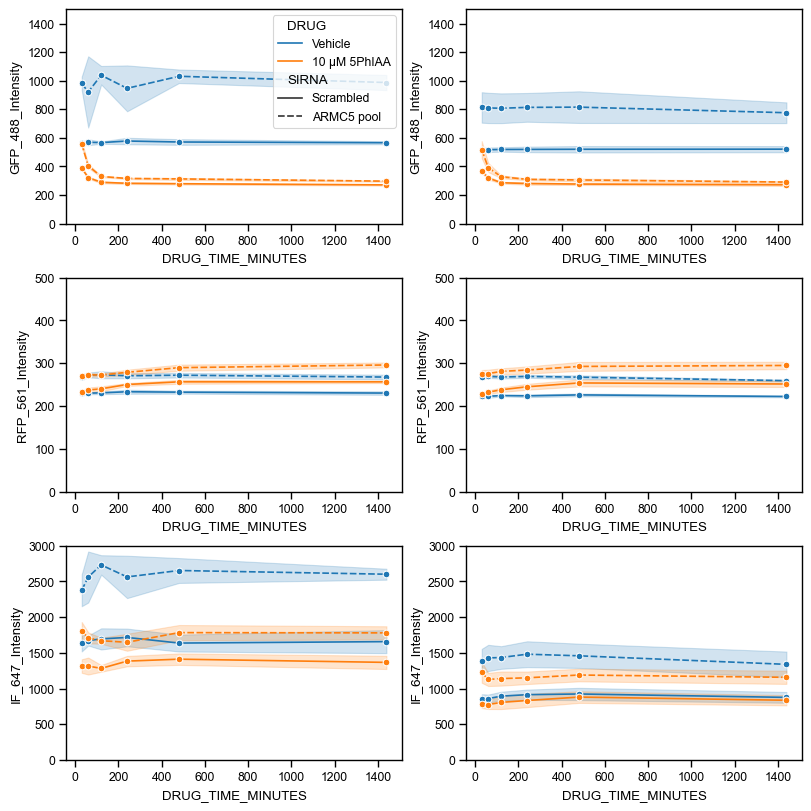

In [46]:
IntensitiesByWell_Experiment1Plot = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG != "No addition"')
IntensitiesByWell_Experiment1Plot['DRUG_TIME_MINUTES'] = IntensitiesByWell_Experiment1Plot.DRUG_TIME_MINUTES.astype('int')

IntensitiesByWell_Experiment2Plot = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG != "No addition"')
IntensitiesByWell_Experiment2Plot['DRUG_TIME_MINUTES'] = IntensitiesByWell_Experiment2Plot.DRUG_TIME_MINUTES.astype('int')

sns.set_context('paper')

f, a = plt.subplots(ncols = 2, nrows = 3, figsize = (8,8), layout = 'constrained')

drug_order = ['Vehicle', '10 µM 5PhIAA']

sirna_order = ['Scrambled', 'ARMC5 pool']

sns.lineplot(IntensitiesByWell_Experiment1Plot,
             x = 'DRUG_TIME_MINUTES',
             y = 'GFP_488_Intensity',
             hue = 'DRUG',  hue_order = drug_order,
             style = 'SIRNA', style_order = sirna_order,
             marker = 'o',
             errorbar = 'sd',
             ax = a[0,0])

sns.lineplot(IntensitiesByWell_Experiment1Plot,
             x = 'DRUG_TIME_MINUTES',
             y = 'RFP_561_Intensity',
             hue = 'DRUG', hue_order = drug_order,
             style = 'SIRNA', style_order = sirna_order,
             marker = 'o',
             errorbar = 'sd',
             ax = a[1,0],
             legend = False)

sns.lineplot(IntensitiesByWell_Experiment1Plot,
             x = 'DRUG_TIME_MINUTES',
             y = 'IF_647_Intensity',
             hue = 'DRUG', hue_order = drug_order,
             style = 'SIRNA', style_order = sirna_order,
             marker = 'o',
             errorbar = 'sd',
             ax = a[2,0],
             legend = False)


sns.lineplot(IntensitiesByWell_Experiment2Plot,
             x = 'DRUG_TIME_MINUTES',
             y = 'GFP_488_Intensity',
             hue = 'DRUG', hue_order = drug_order,
             style = 'SIRNA', style_order = sirna_order,
             marker = 'o',
             errorbar = 'sd',
             ax = a[0,1],
             legend = False)

sns.lineplot(IntensitiesByWell_Experiment2Plot,
             x = 'DRUG_TIME_MINUTES',
             y = 'RFP_561_Intensity',
             hue = 'DRUG', hue_order = drug_order,
             style = 'SIRNA', style_order = sirna_order,
             marker = 'o',
             errorbar = 'sd',
             ax = a[1,1],
             legend = False)

sns.lineplot(IntensitiesByWell_Experiment2Plot,
             x = 'DRUG_TIME_MINUTES',
             y = 'IF_647_Intensity',
             hue = 'DRUG', hue_order = drug_order,
             style = 'SIRNA', style_order = sirna_order,
             marker = 'o',
             errorbar = 'sd',
             ax = a[2,1],
             legend = False)

a[0,0].set_ylim(0,1500)
a[0,1].set_ylim(0,1500)
a[1,0].set_ylim(0,500)
a[1,1].set_ylim(0,500)
a[2,0].set_ylim(0,3000)
a[2,1].set_ylim(0,3000)

## background substract and normalise within each experiment

In [47]:
E1_GFP_Zero = IntensitiesByWell_Experiment1.query('CELL == "HCT116"').GFP_488_Intensity.mean()
E2_GFP_Zero = IntensitiesByWell_Experiment2.query('CELL == "HCT116"').GFP_488_Intensity.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['GFP_488_Intensity'] - E1_GFP_Zero
IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['GFP_488_Intensity'] - E2_GFP_Zero

E1_GFP_NV = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle" & SIRNA == "Scrambled"').GFP_Intensity_BGS.mean()
E2_GFP_NV = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle" & SIRNA == "Scrambled"').GFP_Intensity_BGS.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_FC'] = IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] / E1_GFP_NV
IntensitiesByWell_Experiment2['GFP_Intensity_FC'] = IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] / E2_GFP_NV

In [48]:
E1_RFP_Zero = IntensitiesByWell_Experiment1.query('CELL == "HCT116"').RFP_561_Intensity.mean()
E2_RFP_Zero = IntensitiesByWell_Experiment2.query('CELL == "HCT116"').RFP_561_Intensity.mean()

IntensitiesByWell_Experiment1['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['RFP_561_Intensity'] - E1_RFP_Zero
IntensitiesByWell_Experiment2['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['RFP_561_Intensity'] - E2_RFP_Zero

E1_RFP_NV = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle" & SIRNA == "Scrambled"').RFP_Intensity_BGS.mean()
E2_RFP_NV = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle" & SIRNA == "Scrambled"').RFP_Intensity_BGS.mean()

IntensitiesByWell_Experiment1['RFP_Intensity_FC'] = IntensitiesByWell_Experiment1['RFP_Intensity_BGS'] / E1_RFP_NV
IntensitiesByWell_Experiment2['RFP_Intensity_FC'] = IntensitiesByWell_Experiment2['RFP_Intensity_BGS'] / E2_RFP_NV

In [49]:
IntensitiesByWell = pd.concat([IntensitiesByWell_Experiment1, IntensitiesByWell_Experiment2])

In [50]:
E1_Mouse_Zero = IntensitiesByWell_Experiment1.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa647"').IF_647_Intensity.mean()
E2_Mouse_Zero = IntensitiesByWell_Experiment2.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa647"').IF_647_Intensity.mean()

Total_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('PRIMARY == "Total Pol II (F12)"')
Total_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('PRIMARY == "Total Pol II (F12)"')

Total_IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] = Total_IntensitiesByWell_Experiment1['IF_647_Intensity'] - E1_Mouse_Zero
Total_IntensitiesByWell_Experiment2['IF_647_Intensity_BGS'] = Total_IntensitiesByWell_Experiment2['IF_647_Intensity'] - E2_Mouse_Zero

E1_Total_NV = Total_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle" & SIRNA == "Scrambled"').IF_647_Intensity_BGS.mean()
E2_Total_NV = Total_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle" & SIRNA == "Scrambled"').IF_647_Intensity_BGS.mean()

Total_IntensitiesByWell_Experiment1['IF_647_Intensity_FC'] = Total_IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] / E1_Total_NV
Total_IntensitiesByWell_Experiment2['IF_647_Intensity_FC'] = Total_IntensitiesByWell_Experiment2['IF_647_Intensity_BGS'] / E2_Total_NV

/scratch/pbs.8262740.kman.restech.unsw.edu.au/ipykernel_89353/2878751018.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] = Total_IntensitiesByWell_Experiment1['IF_647_Intensity'] - E1_Mouse_Zero
/scratch/pbs.8262740.kman.restech.unsw.edu.au/ipykernel_89353/2878751018.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Experiment2['IF_647_Intensity_BGS'] = Total_IntensitiesByWell_Experiment2['IF_647_Intensity'] - E2_Mouse

In [51]:
Total_IntensitiesByWell = pd.concat([Total_IntensitiesByWell_Experiment1, Total_IntensitiesByWell_Experiment2])

## fold vehicle treatment in 0 timepoint

In [52]:
def time_in_aux(d,t):
    if d == "Vehicle":
        return 0
    elif d == "No addition":
        return 0
    elif d == "Media only":
        return 0
    elif d == "10 µM 5PhIAA":
        return t

In [53]:
IntensitiesByWell.DRUG.unique()

array(['No addition', 'Vehicle', '10 µM 5PhIAA', 'Media only'],
      dtype=object)

In [54]:
IntensitiesByWell['TIME_IN_AUXIN'] = IntensitiesByWell.apply(lambda x: time_in_aux(x['DRUG'], x['DRUG_TIME_MINUTES']), axis = 1)
IntensitiesByWell['TIME_IN_AUXIN'] = (IntensitiesByWell['TIME_IN_AUXIN'].astype('int'))/60

In [55]:
Total_IntensitiesByWell['TIME_IN_AUXIN'] = Total_IntensitiesByWell.apply(lambda x: time_in_aux(x['DRUG'], x['DRUG_TIME_MINUTES']), axis = 1)
Total_IntensitiesByWell['TIME_IN_AUXIN'] = (Total_IntensitiesByWell['TIME_IN_AUXIN'].astype('int'))/60

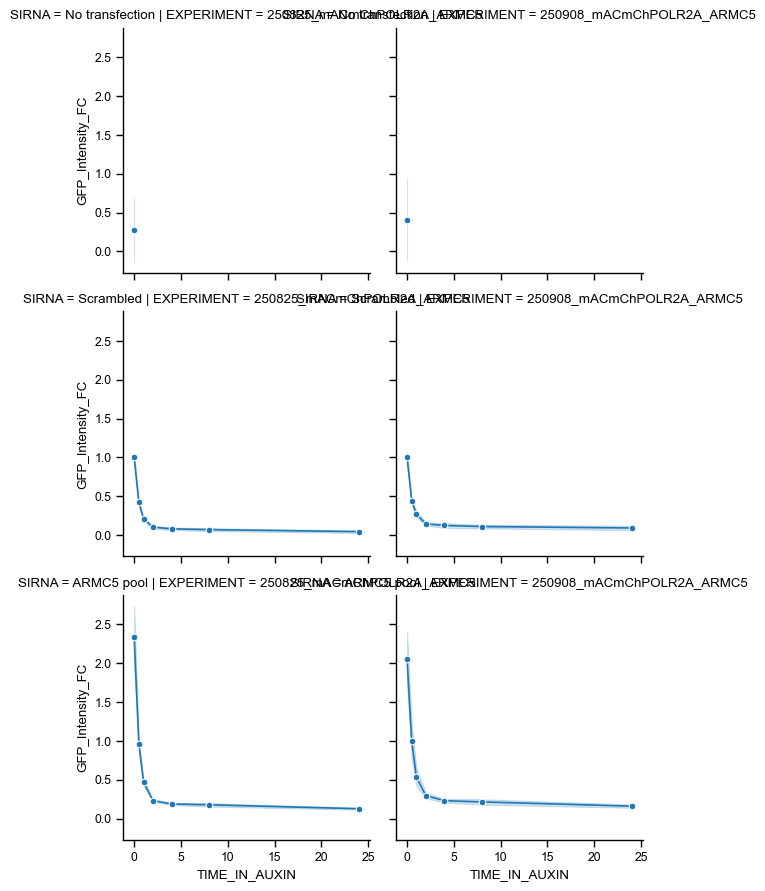

In [56]:
g = sns.FacetGrid(IntensitiesByWell,
                  col = 'EXPERIMENT',
                  row = 'SIRNA')

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN',
                y = 'GFP_Intensity_FC',
                marker = 'o',
                errorbar = 'sd')

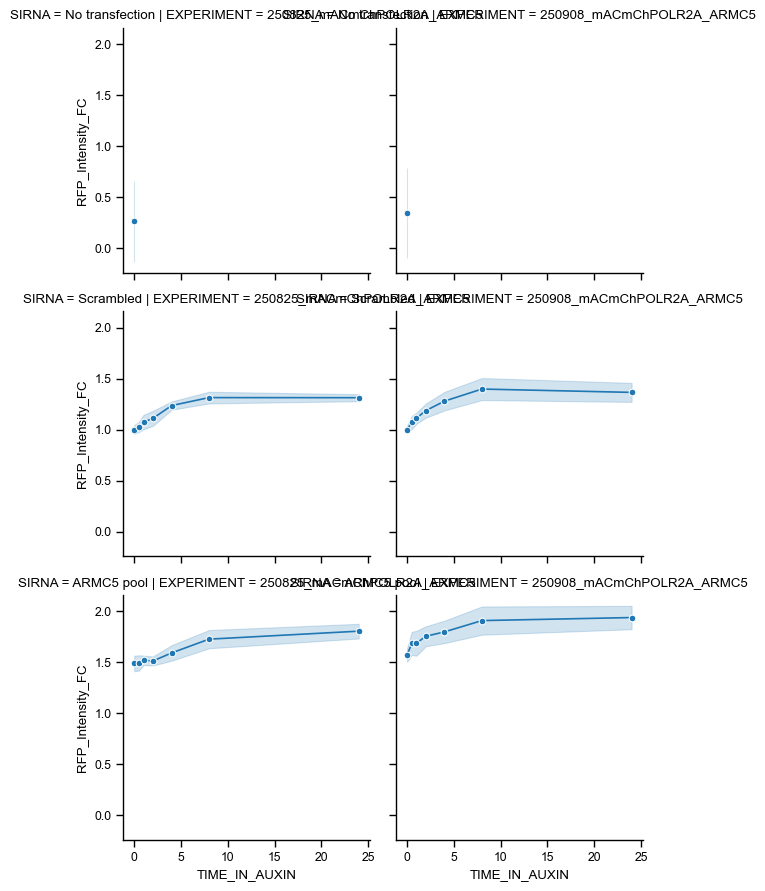

In [57]:
g = sns.FacetGrid(IntensitiesByWell,
                  col = 'EXPERIMENT',
                  row = 'SIRNA')

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN',
                y = 'RFP_Intensity_FC',
                marker = 'o',
                errorbar = 'sd')

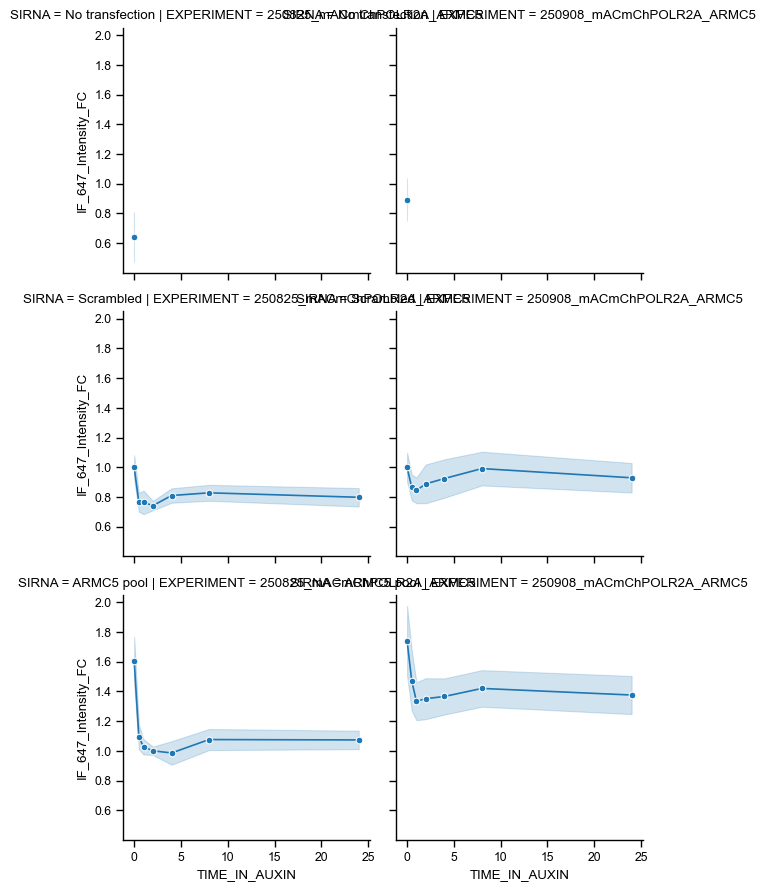

In [58]:
g = sns.FacetGrid(Total_IntensitiesByWell,
                  col = 'EXPERIMENT',
                  row = 'SIRNA')

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN',
                y = 'IF_647_Intensity_FC',
                marker = 'o',
                errorbar = 'sd')

# Plots for manuscript

In [59]:
IntensitiesByWell = IntensitiesByWell.query('SIRNA in ["Scrambled", "ARMC5 pool"]')
Total_IntensitiesByWell = Total_IntensitiesByWell.query('SIRNA in ["Scrambled", "ARMC5 pool"]')

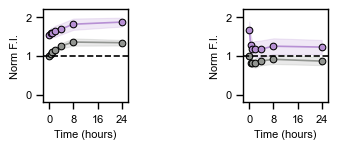

In [60]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (4,1.5), layout = 'constrained')

pal = sns.color_palette(['xkcd:grey', 'xkcd:pale purple'])

h = sns.lineplot(IntensitiesByWell,
             x = 'TIME_IN_AUXIN',
             y = 'RFP_Intensity_FC',
             ax = a[0],
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             hue = 'SIRNA', palette = pal)
h.get_legend().remove()

h = sns.lineplot(Total_IntensitiesByWell,
             x = 'TIME_IN_AUXIN',
             y = 'IF_647_Intensity_FC',
             ax = a[1],
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             hue = 'SIRNA', palette = pal)
h.get_legend().remove()

for j in [0,1]:
    a[j].set_ylim(-0.2,2.2)
    a[j].set_xlim(-2,26)
    a[j].set_xticks(np.linspace(0,24,4))
    a[j].set_box_aspect(1.1)
    a[j].set_xlabel('Time (hours)\n ', fontsize = 8)
    a[j].set_ylabel('Norm F.I.', fontsize = 8)
    a[j].axhline(1, color = 'black', linestyle ='--')
    a[j].tick_params(axis='both', labelsize=8)

plt.savefig('mACmChPOLR2A_TotalPolII_scrambled_ARMC5_KD.svg')